# 1. Title and Objective

## Yield Curve

### Objective

The objective of this report was to build a yield curve that uses term-dependent risk-free rates and discount factors. The yield curve serves as a key piece in the valuatiion as it underpins all pricing and risk analysis. 

# 2. Environments and Import

The required operations including sys, numpy, pandas, and matplotlib.pyplot were installed and imported below. 

In [5]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve

# 3. Methodology Overview

The following four step methodology was applied:

1. Observed market zero rates at discrete maturities (0.25, 2, 3, 5 and 10 years). The market zero rates are Australian Government Bond Yields with 2-, 3-, 5-and 10-year maturities, with a monthly frequency, sourced from the Reserve Bank of Australia.
2. Interpolate zero rates for maturities using the function 'numpy.interp' which performs piecewise linear interpolation between points.
3. Compute discount factors consistently from those interpolated zero rates, using continuous compounding.
4. All code is inside the YieldCurve class in order for all rates and discount factors to be computed.

# 4. Input Yield Curve

The zero rates used to construct the curve are Australian Government Bond Yields with 2-, 3-, 5-and 10-year maturities, published monthly and sourced from the Reserve Bank of Australia. It is noted that the short 0.25-year maturity is proxied from the RBA cash rate target.

The zero rates are observed market prices and are not calibrated to a model. Therefore, the Yield Curve is treated as an input, with any valuation model built inheriting the same market-consistent discount rates. The zero rates loaded for their respective maturities are below:

In [6]:
from src.yieldcurve import YieldCurve, load_rba_yield_curve

curve = load_rba_yield_curve(
    "../data/f1.1-data.csv",
    f2_path="../data/f2-data.csv",
    compounding="continuous"
)

Using yield curve data from: 07-May-2026


In [7]:
test_maturites = [0.25, 2.0, 3.0]

for T in test_maturites:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T={T:.2f} years | zero rate={z:.2%} | discount factor={d:.4f}")

T=0.25 years | zero rate=4.10% | discount factor=0.9898
T=2.00 years | zero rate=4.64% | discount factor=0.9113
T=3.00 years | zero rate=4.60% | discount factor=0.8710


# 5. Construct the Yield Curve Object

The YieldCurve class is instantiated with the above market maturities and zero rates using continuous compounding. Continuous compounding is the standard measure in the Black-Scholes derivative pricing model and takes the formula of:

$$P(0,T) = e^{-z(T) \cdot T}$$

All downstream models call 'get_zero_rate' or 'get_discount_factor', meaning any changes to market data (eg: updated RBA cash rates) updates all downstream models without further modification.

# 6. Sanity Checks

To verify if the Yield Curve object behaves correctly, sanity checks were performed to test two fundamental properties of a Yield Curve:

1. Zero rates should increase with maturity as longer horizons reflect uncertainty and liquidity risk, hence investors demand a higher return.
2. Discount factors should decrease with maturity as money into the future is worth less today.

In [9]:
test_maturites = [0.25, 2.0, 3.0]

for T in test_maturites:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T={T:.2f} years | zero rate={z:.2%} | discount factor={d:.4f}")

T=0.25 years | zero rate=4.10% | discount factor=0.9898
T=2.00 years | zero rate=4.64% | discount factor=0.9113
T=3.00 years | zero rate=4.60% | discount factor=0.8710


# 7. Yield Curve Plot

The plot below visualises the full-term structure from 3 months to 10 years. As observed, the curve is upwards sloping in nature as the zero rates rise steadily across all maturities.

**Key Observations**

- Between 3 months – 2 years, the curve rises steeply, as rates increase by 23bp from 4.10% (cash rate proxy) to 4.64% (2-year bond yield)
- The curve inverts slightly between 2-3 years, dipping from 4.64% to 4.60%, before recovering at the 5-year maturity of 4.63%
- The curve steepens again from 5-10 years, rising from 4.63% to 4.93%. This reflects the compensation investors demand as longer-dated bonds carry a higher premium.

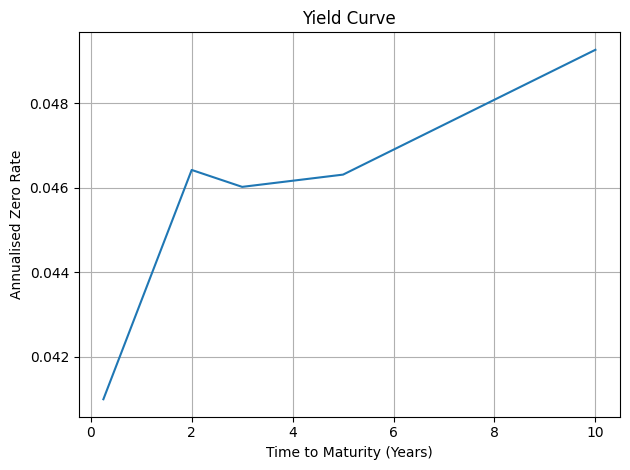

In [8]:
curve.plot()